# Titanic analysis

In [3]:
# import modules
import seaborn as sns
import pandas as pd 
import matplotlib.pyplot as plt

In [6]:
# get a brief overview of the data used within the tables
titanic = sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Text(0.5, 1.0, 'Amount of survivors')

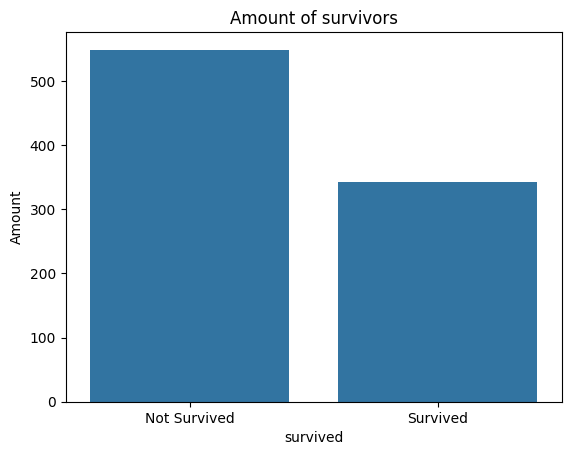

In [7]:
# this will return a df in this format:
# survived
# 0 {amount of didnt survive}
# 1 {amount of survived}
counts = titanic["survived"].value_counts()

# puts the column values (0 and 1) on the x axis, with the values on the y axis
sns.barplot(x=counts.index, y=counts.values)

# renames the x axis values from 0 and 1 to not survived and survived for better viewing
plt.xticks([0, 1], ["Not Survived", "Survived"])
plt.ylabel("Amount")
plt.title("Amount of survivors")

From the data, we can analyse that majority of the people on the titanic did not survive with a rough ratio of 5:3 non survivors

Text(0.5, 1.0, 'Survival by Sex')

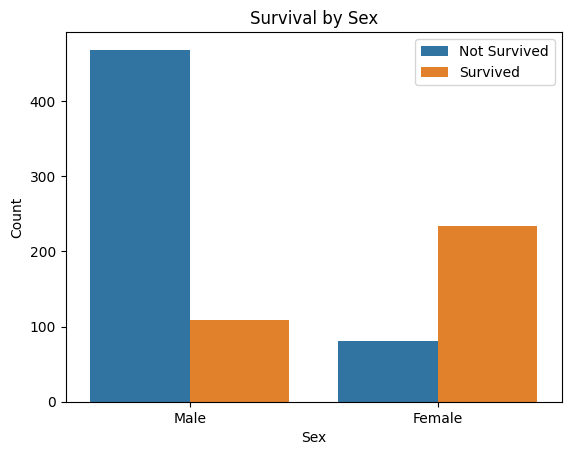

In [8]:
# get the amount of survivors based on sex
plot = sns.countplot(x="sex", hue="survived", data=titanic)

# change the values of the legend
plot.legend(['Not Survived','Survived'])

plt.xlabel("Sex")
plt.ylabel("Count")

# capitalise the categories
plt.xticks([0,1], ["Male","Female"])

plt.title("Survival by Sex")

From the above chart, we can see that majority of the survivors were female. But this evidence alone is not conclusive, as it seems there was more males overall. 

Text(0, 0.5, 'Count')

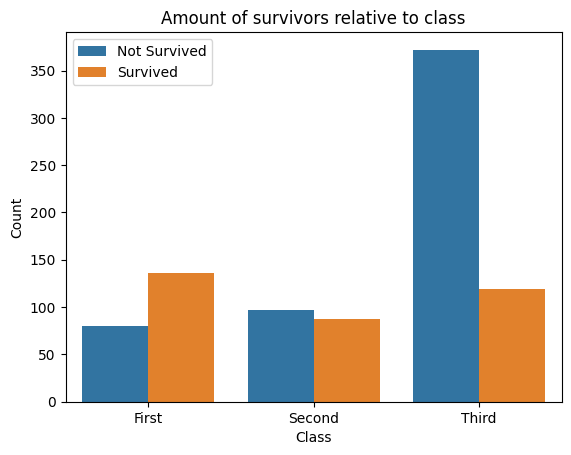

In [9]:
# titanic.groupby("class")["survived"].value_counts()

plot = sns.countplot(x="class", hue="survived", data=titanic)

# change the values of the legend
plot.legend(['Not Survived','Survived'])

plt.title("Amount of survivors relative to class")
plt.xlabel("Class")
plt.ylabel("Count")

From the chart, we can see that although the overall amount of survivers in each class is similar, the actual survival rate changes drastically across classes. First class sees more survivors than non survivors and second class has a near equal amount of survivors as non survivors. Compared to third class where the ratio of survivors is significantly lower than the 2 other classes.

From the data provided, it is clear to see that higher class passengers had a much higher survival rate

In [10]:
titanic.groupby("class")["survived"].mean()

class
First     0.629630
Second    0.472826
Third     0.242363
Name: survived, dtype: float64

Looking at the raw averages, we can see that first class passengers had a significantly higher rate of survival

In [11]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Text(0, 0.5, 'Average')

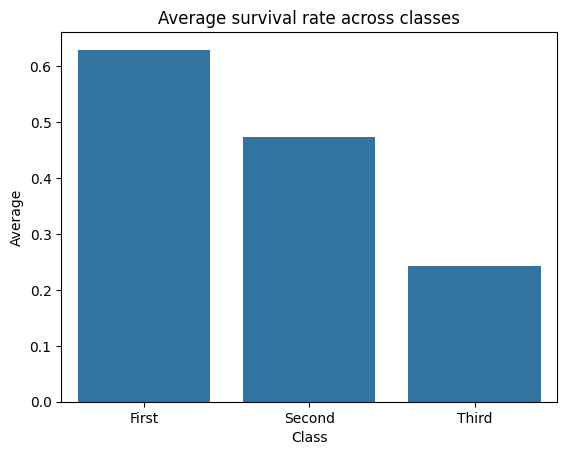

In [12]:
average_survival_rate = titanic.groupby("class")["survived"].mean()

sns.barplot(x=average_survival_rate.index, y=average_survival_rate.values)
plt.title("Average survival rate across classes")
plt.xlabel("Class")
plt.ylabel("Average")

<Axes: title={'center': 'Average survival rates across ages'}, xlabel='Age', ylabel='Survival Percentage'>

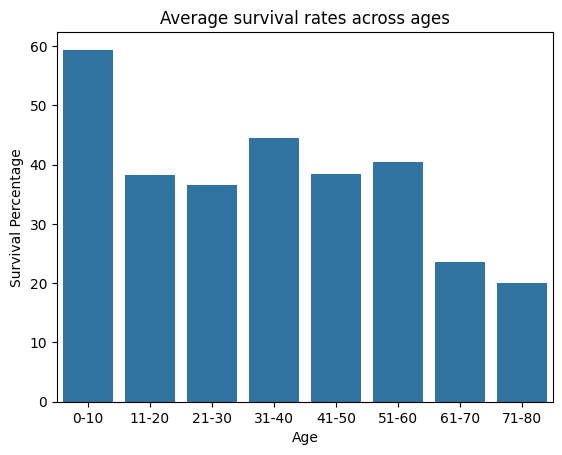

In [20]:
# drop the rows that don't have an age value
age_data = titanic.dropna(subset=["age"])

# create an extra col that sets an age_group based on the users age
# this will be used to group the ages for analysis
age_data["age_group"] = pd.cut(
    age_data["age"], 
    bins=[0,10,20,30,40,50,60,70,80], 
    labels=["0-10","11-20","21-30","31-40","41-50","51-60","61-70","71-80"]
)

# reset index is used to turn it back into normal dataframe formatting, so that there is indexes for each row
avg_survival = age_data.groupby("age_group")["survived"].mean().reset_index() 
avg_survival["survived_percent"] = (avg_survival["survived"] * 100).round(2)

plt.title("Average survival rates across ages")
plt.xlabel("Age")
plt.ylabel("Survival Percentage")

sns.barplot(x="age_group", y="survived_percent", data=avg_survival)

From the plot above, we can see that children had the highest survival rates, whilst older people had the lowest survival rates, whereas the ages between 20-60 had no strong distinctions between them

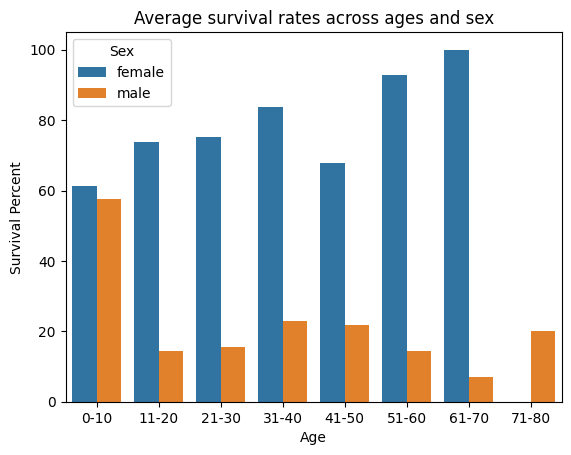

In [43]:
avg_survival_by_sex = age_data.groupby(["age_group", "sex"])["survived"].mean().reset_index()
avg_survival_by_sex["survived_percent"] = (avg_survival_by_sex["survived"] * 100).round(2)

sns.barplot(x="age_group", y="survived_percent", hue="sex", data=avg_survival_by_sex)

plt.title("Average survival rates across ages and sex")
plt.xlabel("Age")
plt.ylabel("Survival Percent")
plt.legend(title="Sex")

From the plot above, we can see that aside from both ends of the age spectrum, women were the primary survivors